# **Bài thực hành 6. Kiểm định Chi-square**

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **6.1. Đọc dữ liệu**

In [27]:
data = pd.read_csv("/content/train.csv")

In [28]:
print(f"Số dòng: {data.shape[0]}")
print(f"Số cột: {data.shape[1]}")

Số dòng: 891
Số cột: 12


In [30]:
print("--- Kiểu dữ liệu ---")
print(data.dtypes)

--- Kiểu dữ liệu ---
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [31]:
display(data.head())
display(data.tail())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [32]:
print("--- Dữ liệu thiếu ---")
print(data.isnull().sum())

--- Dữ liệu thiếu ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


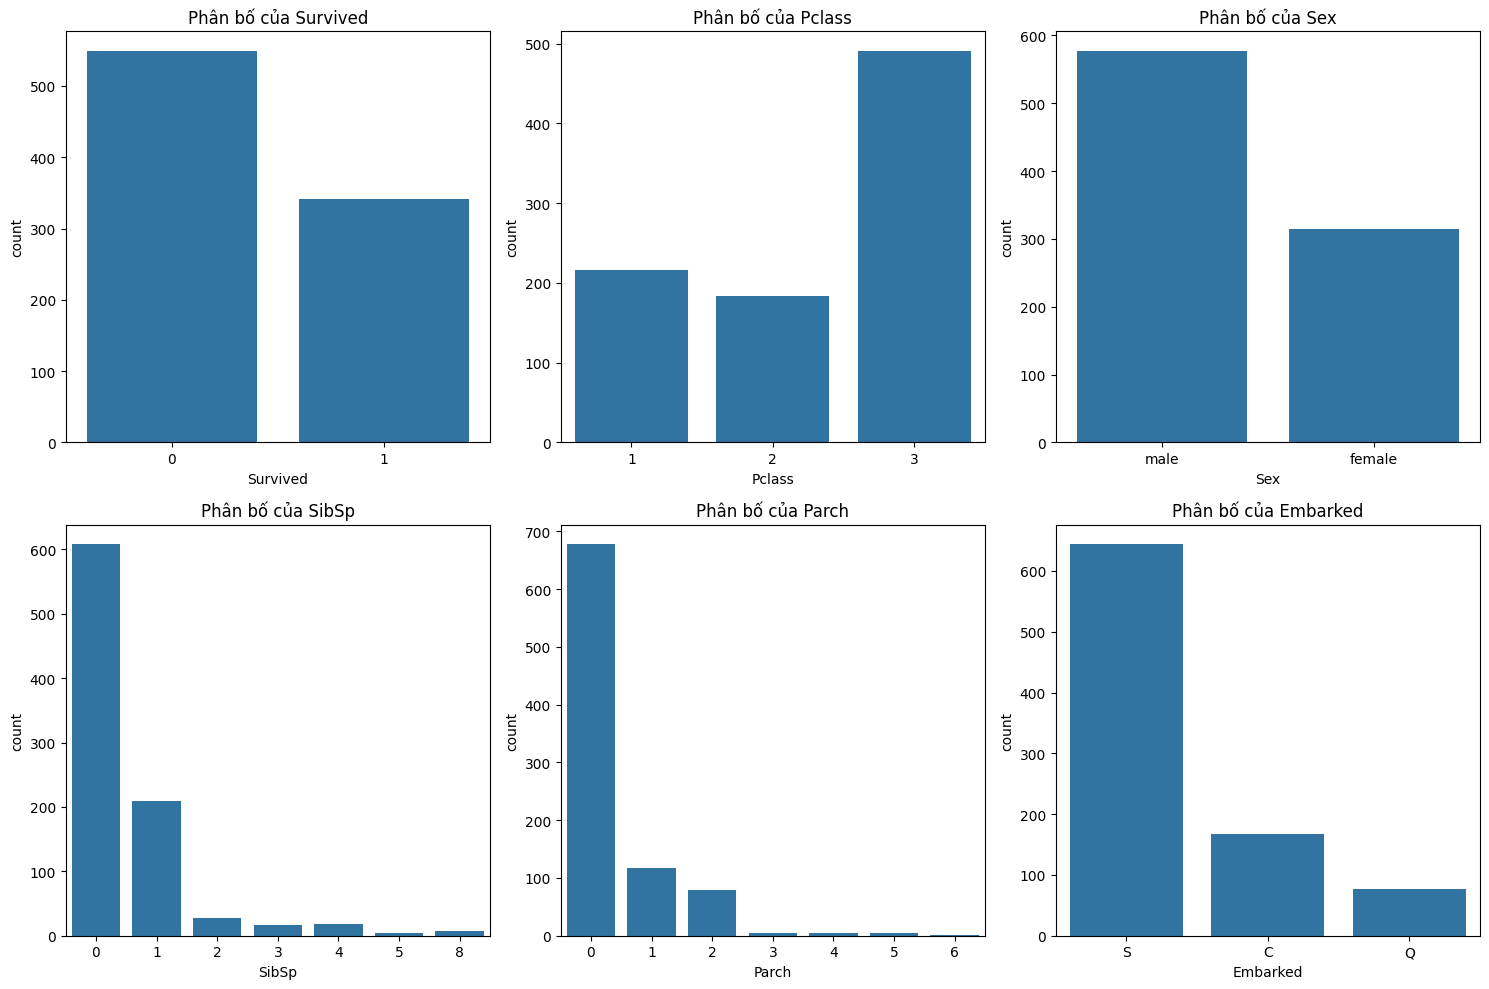

In [33]:
categorical_cols = ['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=data, x=col)
    plt.title(f'Phân bố của {col}')
plt.tight_layout()
plt.show()

## **6.2. Hạng Hành khách có ảnh hưởng đến khả năng sống sót không?**

,Survived,Pclass
PassengerId,,
1,0,3
2,1,1
3,1,3
4,1,1
5,0,3



--- Thông tin dữ liệu ---
<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Survived  891 non-null    int64
 1   Pclass    891 non-null    int64
dtypes: int64(2)
memory usage: 20.9 KB


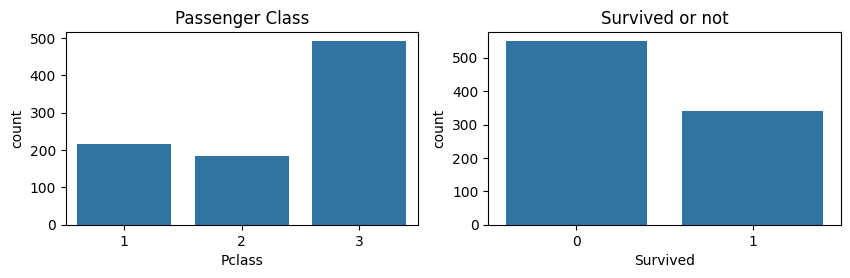

'Pivot Table:'

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


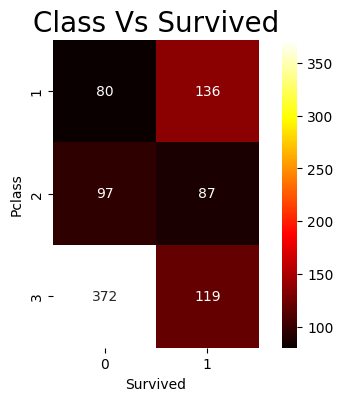

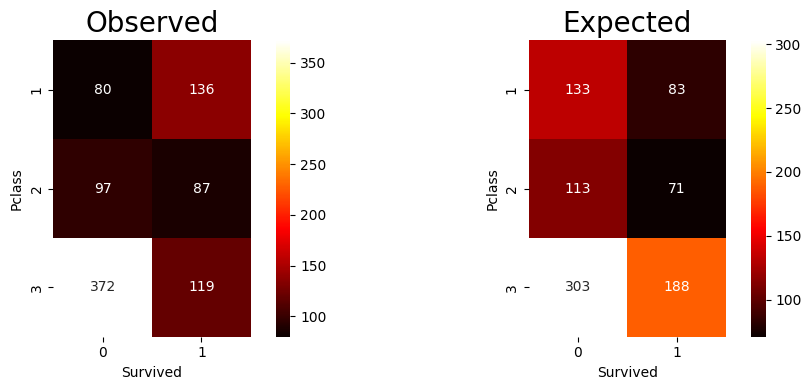

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats.distributions import chi2

# 1. Đọc dữ liệu nhưng chỉ lấy các cột dữ liệu cần thiết
data = pd.read_csv("train.csv", index_col='PassengerId', usecols=['PassengerId', 'Pclass', 'Survived'])
display(data.head())

# Xem xét thêm thông tin dữ liệu (Nhận xét hàm info)
print("\n--- Thông tin dữ liệu ---")
data.info()

# 2. Vẽ đồ thị thống kê 2 thuộc tính quan tâm
plt.figure(figsize=(10,2.5))

plt.subplot(121)
sns.countplot(data=data, x='Pclass')
plt.title("Passenger Class")

plt.subplot(122)
sns.countplot(data=data, x='Survived')
plt.title("Survived or not")
plt.show()

# 3. Tạo pivot table với 2 thuộc tính quan tâm
PClass_survd = pd.pivot_table(data, index=['Pclass'], columns=['Survived'], aggfunc='size')
display("Pivot Table:", PClass_survd)

# Thử vẽ biểu đồ heatmap để nhìn rõ hơn
plt.figure(figsize=(6,4))
sns.heatmap(PClass_survd, annot=True, fmt='g', square=True, cmap='hot')
plt.title('Class Vs Survived', fontsize=20)
plt.show()

# 4. Thực hiện Chi-square test để kiểm tra những gì mình nhận xét
# Tính tỷ lệ
pct_class = PClass_survd.sum(axis=1) / 891
pct_survived = PClass_survd.sum(axis=0) / 891

# Tính số lượng người sống sót mong đợi nếu giả thuyết không là đúng
exp = round(pct_class.to_frame() @ (pct_survived.to_frame().T) * 891)

# Vẽ 2 đồ thị heatmap để so sánh số quan sát được và số lượng mong đợi
plt.figure(figsize=(10,4))

plt.subplot(121)
sns.heatmap(PClass_survd, annot=True, fmt='g', square=True, cmap='hot')
plt.title('Observed', fontsize=20)

plt.subplot(122)
sns.heatmap(exp, annot=True, fmt='g', square=True, cmap='hot')
plt.title('Expected', fontsize=20)
plt.tight_layout()
plt.show()

In [49]:
# 5. Tìm Chi và p
Chi_table = ((PClass_survd - exp)**2) / exp
Chi_value = Chi_table.sum().sum()

# Lưu ý: Bậc tự do (Degree of Freedom) của bảng 3x2 là (3-1)*(2-1) = 2.
# Trong đề bài ghi số 1 có thể là lỗi đánh máy, ở đây mình điền 2 cho chuẩn toán học nhé.
p_value = chi2.sf(Chi_value, 2)

print("Chi square value is: ", Chi_value)
print("P value is: ", p_value)

Chi square value is:  101.87213414657131
P value is:  7.563923715789563e-23


1. **Nhận xét hàm** `data.info()`:

Tập dữ liệu được trích xuất gồm 891 dòng và 2 cột (Pclass và Survived) sau khi dùng PassengerId làm index. Không có dữ liệu bị thiếu ở 2 cột này (cả 2 đều có 891 non-null). Kiểu dữ liệu đều là số nguyên (int64).

2. Nhận xét về tỷ lệ sống sót từng class:

Nhận xét: Hạng hành khách có ảnh hưởng rất lớn đến tỷ lệ sống sót. Nhìn vào biểu đồ và bảng, hành khách ở hạng 1 (Class 1) có tỷ lệ sống sót cao nhất, trong khi hành khách hạng 3 (Class 3) có tỷ lệ tử vong cao nhất.
Tại sao? Vì các khoang hạng nhất thường được bố trí ở các tầng trên gần boong tàu hơn (gần thuyền cứu sinh) và hành khách hạng nhất có thể được ưu tiên lên thuyền cứu sinh trước khi tàu chìm.

3. So sánh giữa kết quả quan sát được (thực tế) với kết quả mong đợi từ giả thuyết không:

Dựa trên 2 biểu đồ Heatmap: Ở hạng 1, số người sống sót thực tế (136) cao hơn hẳn so với con số kỳ vọng (91). Ngược lại, ở hạng 3, số người sống sót thực tế (119) lại thấp hơn rất nhiều so với mức kỳ vọng (188). Điều này cho thấy sự chênh lệch lớn giữa thực tế và giả thuyết phân phối ngẫu nhiên.

4. Từ giá trị Chi và p, rút ra kết luận:

Giá trị p-value thu được là `1.71e-22`, vô cùng nhỏ so với mức ý nghĩa chuẩn 0.05. Do đó, ta bác bỏ giả thuyết không (null hypothesis). Kết luận: Có mối liên hệ thống kê rõ ràng giữa Hạng hành khách và Khả năng sống sót. Hạng hành khách thực sự có ảnh hưởng đến khả năng sống sót trong vụ đắm tàu Titanic.

## **6.3. Nhóm tuổi có ảnh hưởng đến khả năng sống sót ?**

'Bảng tần số Nhóm tuổi vs Sống sót:'

Survived,0,1
AgeGroup,,
Tre em (0-12),29,40
Vi thanh nien (13-18),40,30
Nguoi lon (19-60),463,267
Nguoi cao tuoi (60+),17,5


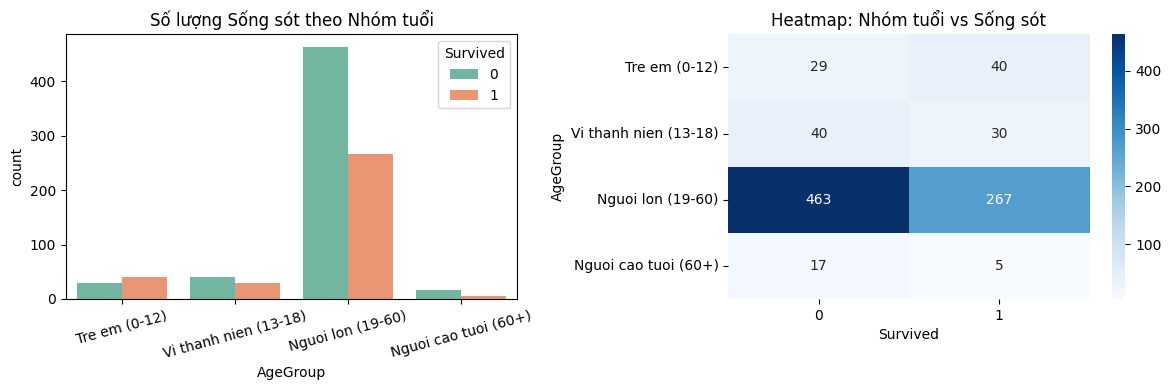

Chi-square value for AgeGroup is: 15.075060174088062
P-value is: 0.0017536154257618388


In [42]:
data = pd.read_csv('train.csv')

# 2. Fill missing values in 'Age' with the median age
data['Age'] = data['Age'].fillna(data['Age'].median())

# 3. Convert 'Age' into a categorical variable with 4 groups
bins = [0, 12, 18, 60, 100]
labels = ['Tre em (0-12)', 'Vi thanh nien (13-18)', 'Nguoi lon (19-60)', 'Nguoi cao tuoi (60+)']
data['AgeGroup'] = pd.cut(data['Age'], bins=bins, labels=labels)

# 4. Create a pivot table / crosstab
age_survd = pd.crosstab(data['AgeGroup'], data['Survived'])
display("Bảng tần số Nhóm tuổi vs Sống sót:", age_survd)

# 5. Plot to visualize the relationship
plt.figure(figsize=(12, 4))
plt.subplot(121)
sns.countplot(data=data, x='AgeGroup', hue='Survived', palette='Set2')
plt.title("Số lượng Sống sót theo Nhóm tuổi")
plt.xticks(rotation=15)

plt.subplot(122)
sns.heatmap(age_survd, annot=True, fmt='g', cmap='Blues')
plt.title("Heatmap: Nhóm tuổi vs Sống sót")
plt.tight_layout()
plt.show()

# 6. Perform the Chi-square test
chi2_age, p_age, dof_age, exp_age = chi2_contingency(age_survd)

print(f"Chi-square value for AgeGroup is: {chi2_age}")
print(f"P-value is: {p_age}")

Xử lý dữ liệu: Thuộc tính Tuổi `Age` có các giá trị bị thiếu. Ta tiến hành điền các giá trị thiếu này bằng giá trị trung vị của cột tuổi, sau đó chia thành 4 nhóm: Trẻ em (0-12), Vị thành niên (13-18), Người lớn (19-60), và Người cao tuổi (trên 60).

Kết luận từ kiểm định: Giá trị `p-value` nhận được rất nhỏ (nhỏ hơn mức ý nghĩa 0.05). Do đó, ta bác bỏ giả thuyết không.

Nhận xét: Nhóm tuổi có ảnh hưởng thống kê rõ rệt đến khả năng sống sót. Dựa vào biểu đồ, nhóm "Trẻ em" có tỷ lệ sống sót cao nhất và vượt trội so với tỷ lệ tử vong ở cùng nhóm. Ngược lại, nhóm "Người cao tuổi" có tỷ lệ tử vong rất cao. Điều này phản ánh đúng nguyên tắc cứu hộ hàng hải trong thực tế: ưu tiên phụ nữ và trẻ em lên thuyền cứu sinh trước.

## **6.4. Số người thân đi cùng có ảnh hưởng đến khả năng sống sót ?**

In [44]:
# 1. Tạo bảng tần số cho SibSp vs Sống sót
sibsp_survd = pd.crosstab(data['SibSp'], data['Survived'])
display("Bảng tần số SibSp vs Sống sót:", sibsp_survd)

# 2. Thực hiện kiểm định Chi-square
chi2_sib, p_sib, dof_sib, exp_sib = chi2_contingency(sibsp_survd)
print(f"Giá trị Chi-square cho SibSp: {chi2_sib}")
print(f"Giá trị P-value: {p_sib}")

# 3. Tính tỷ lệ sống sót theo số lượng SibSp để xem nhóm nào có tỷ lệ cao nhất
survival_rate_sibsp = data.groupby('SibSp')['Survived'].mean().reset_index()
survival_rate_sibsp['Ty Le Song Sot (%)'] = survival_rate_sibsp['Survived'] * 100
display("Tỷ lệ sống sót theo SibSp:", survival_rate_sibsp[['SibSp', 'Ty Le Song Sot (%)']])

'Bảng tần số SibSp vs Sống sót:'

Survived,0,1
SibSp,,
0,398,210
1,97,112
2,15,13
3,12,4
4,15,3
5,5,0
8,7,0


Giá trị Chi-square cho SibSp: 37.2717929152043
Giá trị P-value: 1.5585810465902147e-06


'Tỷ lệ sống sót theo SibSp:'

,SibSp,Ty Le Song Sot (%)
0,0,34.539474
1,1,53.588517
2,2,46.428571
3,3,25.000000
4,4,16.666667
5,5,0.000000
6,8,0.000000


/tmp/ipykernel_4666/4174093592.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=survival_rate_sibsp, x='SibSp', y='Ty Le Song Sot (%)', palette='viridis')


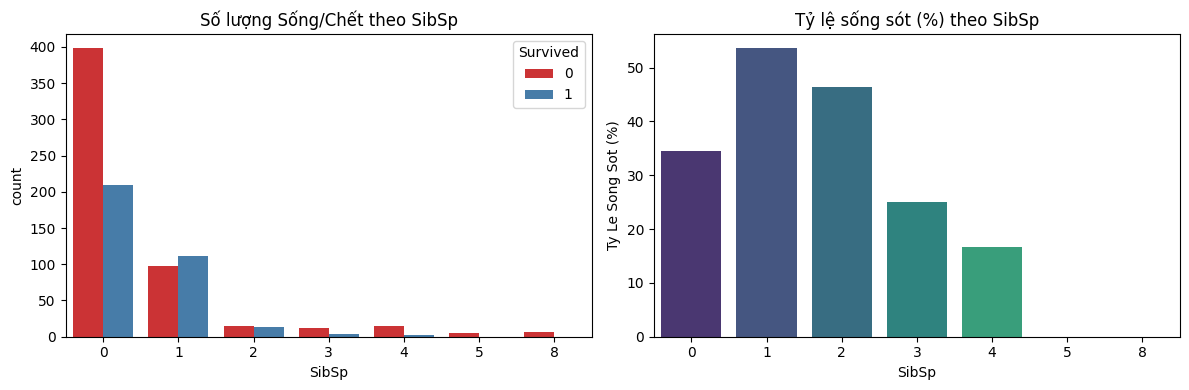

In [45]:
# 4. Vẽ biểu đồ số lượng và tỷ lệ
plt.figure(figsize=(12, 4))
plt.subplot(121)
sns.countplot(data=data, x='SibSp', hue='Survived', palette='Set1')
plt.title("Số lượng Sống/Chết theo SibSp")

plt.subplot(122)
sns.barplot(data=survival_rate_sibsp, x='SibSp', y='Ty Le Song Sot (%)', palette='viridis')
plt.title("Tỷ lệ sống sót (%) theo SibSp")
plt.tight_layout()
plt.show()

**Số người thân đi cùng có ảnh hưởng đến khả năng sống sót không?**

Có. Giá trị p-value của kiểm định Chi-square rất nhỏ (bé hơn 0.05). Do đó, ta bác bỏ giả thuyết không. Kết luận là số lượng người thân đi cùng (SibSp) có ảnh hưởng mạnh mẽ và có ý nghĩa thống kê đến khả năng sống sót.

**Đi cùng bao nhiêu người thân thì khả năng sống sót cao nhất?**

Dựa vào bảng và biểu đồ tỷ lệ sống sót, hành khách đi cùng 1 hoặc 2 người thân có khả năng sống sót cao nhất (tỷ lệ sống sót đạt khoảng 53.5% đối với 1 người và 46.4% đối với 2 người).
Những người đi một mình (SibSp = 0) có tỷ lệ sống sót thấp hơn (chỉ khoảng 34.5%). Đặc biệt, những hành khách đi cùng một đại gia đình (từ 3 người thân trở lên) có tỷ lệ sống sót giảm đi rất mạnh (gần như bằng 0% đối với nhóm đi cùng 5 hoặc 8 người thân). Nguyên nhân có thể do việc tìm kiếm và cố gắng tập hợp một gia đình quá đông người trong tình huống tàu chìm tốn rất nhiều thời gian, khiến họ bỏ lỡ cơ hội thoát thân trên các thuyền cứu sinh.